This notebook shows the effect of $\xi_\eta$ anisotropy on the 21-cm power spectrum, controlled by the `USE_ANISO_XI_ETA` flag in this modification.

All other parameter values (except `precisionboost`) are left at default.

## Module imports

In [1]:
import numpy as np
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

from cycler import cycler
from types import SimpleNamespace
import zeus21 as zeus21_hack

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

## Zeus setup

Takes a few minutes to run.

In [2]:
UserParams = zeus21_hack.User_Parameters(precisionboost=1.2)

# Base code
CosmoParams_base = zeus21_hack.Cosmo_Parameters(UserParams=UserParams,
                                           USE_RELATIVE_VELOCITIES=True)
AstroParams_base = zeus21_hack.Astro_Parameters(CosmoParams=CosmoParams_base,
                                           USE_POPIII=True)
HMFinterp_base = zeus21_hack.HMF_interpolator(User_Parameters=UserParams, 
                                              Cosmo_Parameters=CosmoParams_base)
Coeffs_base = zeus21_hack.get_T21_coefficients(UserParams, CosmoParams_base, 
                                               AstroParams_base, HMFinterp_base)
PS_base = zeus21_hack.Power_Spectra(UserParams, CosmoParams_base, AstroParams_base, Coeffs_base)

# With anisotropic xi_eta
CosmoParams_aniso = zeus21_hack.Cosmo_Parameters(UserParams=UserParams,
                                           USE_RELATIVE_VELOCITIES=True,
                                           USE_ANISO_XI_ETA=True)
AstroParams_aniso = zeus21_hack.Astro_Parameters(CosmoParams=CosmoParams_aniso,
                                           USE_POPIII=True)
HMFinterp_aniso = zeus21_hack.HMF_interpolator(User_Parameters=UserParams, 
                                               Cosmo_Parameters=CosmoParams_aniso)
Coeffs_aniso = zeus21_hack.get_T21_coefficients(UserParams, CosmoParams_aniso, 
                                               AstroParams_aniso, HMFinterp_aniso)
PS_aniso = zeus21_hack.Power_Spectra(UserParams, CosmoParams_aniso, AstroParams_aniso, Coeffs_aniso)

/Users/yuranzhang/Zeus21_prod/zeus21/sfrd.py:568: RuntimeWarning: invalid value encountered in log
  darr1_darr2 =  np.log(arr1[:,:,midpoint+1]/arr1[:,:,midpoint-1]) / (arr2[:,:,0,midpoint+1] - arr2[:,:,0,midpoint-1])
/Users/yuranzhang/Zeus21_prod/zeus21/sfrd.py:572: RuntimeWarning: invalid value encountered in log
  der1_II =  np.log(arr1[:,:,midpoint]/arr1[:,:,midpoint-1])/(arr2[:,:,0,midpoint] - arr2[:,:,0,midpoint-1]) #ln(y2/y1)/(x2-x1)


## Plot \& compare

In [3]:
rlist = CosmoParams_base._Rtabsmoo
zlist = Coeffs_base.zintegral
klist = PS_base.klist_PS
R1choose = 0
R2choose = 0

### $\xi_\eta(r)$

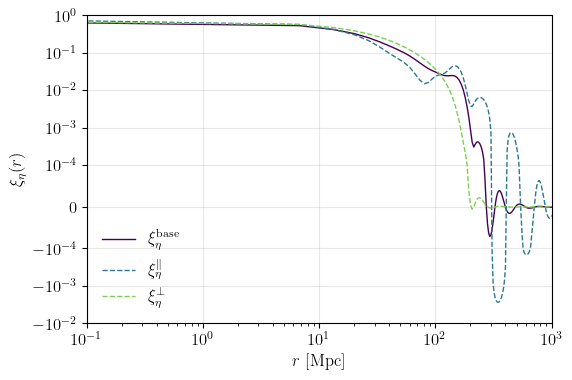

In [4]:
xiEta_base = CosmoParams_base.xiEta_RR_CF[R1choose, R2choose, :]
xiEta_para = CosmoParams_aniso.xiEtaPara_RR_CF[R1choose, R2choose, :]
xiEta_perp = CosmoParams_aniso.xiEtaPerp_RR_CF[R1choose, R2choose, :]

rdense = np.linspace(rlist[0], rlist[-1], 300)
xiEta_base_interp = interp1d(rlist, xiEta_base, axis=0, kind='cubic')
xiEta_para_interp = interp1d(rlist, xiEta_para, axis=0, kind='cubic')
xiEta_perp_interp = interp1d(rlist, xiEta_perp, axis=0, kind='cubic')
xiEta_base_dense = xiEta_base_interp(rdense)
xiEta_para_dense = xiEta_para_interp(rdense)
xiEta_perp_dense = xiEta_perp_interp(rdense)

colors = mpl.colormaps["viridis"](np.linspace(0.0, 0.8, 3))
mpl.rcParams["axes.prop_cycle"] = cycler(color=colors)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rdense, xiEta_base_dense, lw=1, label=r'$\xi_{\eta}^{\mathrm{base}}$')
ax.plot(rdense, xiEta_para_dense, ls='--', lw=1, label=r'$\xi_{\eta}^{\parallel}$')
ax.plot(rdense, xiEta_perp_dense, ls='--', lw=1, label=r'$\xi_{\eta}^{\perp}$')
ax.set_xlim(1e-1, 1e3)
ax.set_ylim(-1e-2, 1)
ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=1e-4)
ax.set_xlabel(r'$r$ [Mpc]')
ax.set_ylabel(r'$\xi_{\eta}(r)$')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, frameon=False, loc='lower left')

### Temperatures (no difference)

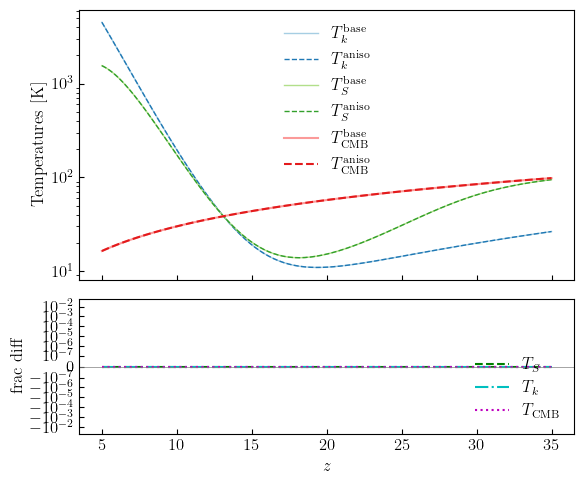

In [5]:
colors = mpl.colormaps["Paired"].colors
mpl.rcParams["axes.prop_cycle"] = cycler(color=colors)

Ts_base = 1.0/Coeffs_base._invTs_avg
Ts_aniso   = 1.0/Coeffs_aniso._invTs_avg

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True, gridspec_kw={'height_ratios':[2,1]})

ax1.plot(zlist, Coeffs_base.Tk_avg, lw=1, label=r'$T_k^{\rm base}$')
ax1.plot(zlist, Coeffs_aniso.Tk_avg, ls='--', lw=1, label=r'$T_k^{\rm aniso}$')

ax1.plot(zlist, Ts_base, lw=1, label=r'$T_S^{\rm base}$')
ax1.plot(zlist, Ts_aniso, ls='--', lw=1, label=r'$T_S^{\rm aniso}$')

ax1.plot(zlist, Coeffs_base.T_CMB, label=r'$T_{\rm CMB}^{\rm base}$')
ax1.plot(zlist, Coeffs_aniso.T_CMB, ls='--', label=r'$T_{\rm CMB}^{\rm aniso}$')

ax1.set_ylabel(r'Temperatures [K]')
ax1.set_yscale('log')
ax1.tick_params(direction='in')
ax1.legend(fontsize=12, frameon=False)

ax2.plot(zlist, (Ts_base - Ts_aniso) / Ts_aniso, 'g', ls='--', label=r'$T_S$')
ax2.plot(zlist, (Coeffs_aniso.Tk_avg - Coeffs_base.Tk_avg) / Coeffs_base.Tk_avg, 'c', ls='-.', label=r'$T_k$')
ax2.plot(zlist, (Coeffs_base.T_CMB - Coeffs_aniso.T_CMB) / Coeffs_aniso.T_CMB, 'm', ls=':', label=r'$T_{\rm CMB}$')
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_yscale('symlog', linthresh=1e-7)
ax2.set_ylabel('frac diff')
ax2.set_xlabel(r'$z$')
ax2.tick_params(direction='in')
ax2.legend(fontsize=12, frameon=False, loc='lower right')
plt.tight_layout()


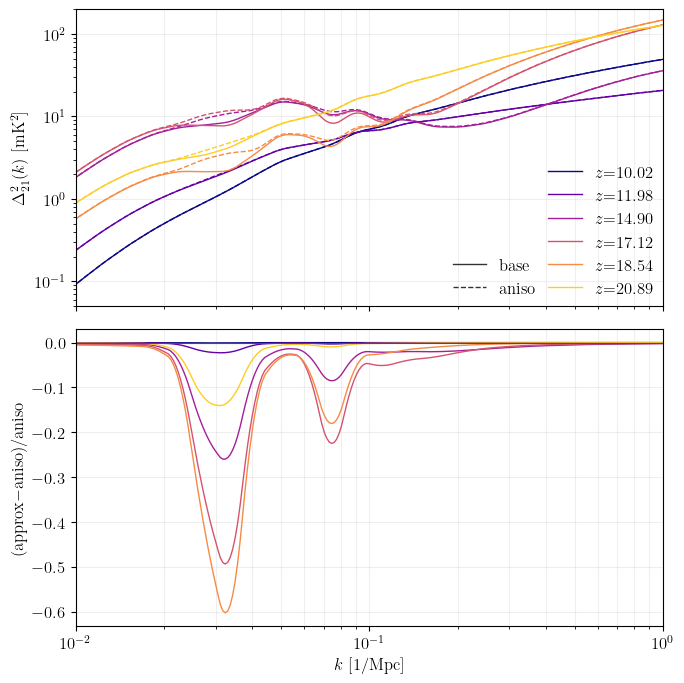

In [6]:
z_targets = np.array([10.0, 12.0, 15.0, 17.0, 18.7, 21.0])
z_idx = [int(np.argmin(np.abs(zlist - z))) for z in z_targets]
z_samples = zlist[z_idx]

interp_base = interp1d(zlist, PS_base.Deltasq_T21, axis=0, bounds_error=False, fill_value="extrapolate")
interp_aniso = interp1d(zlist, PS_aniso.Deltasq_T21, axis=0, bounds_error=False, fill_value="extrapolate")

P21_base = interp_base(z_samples)
P21_aniso = interp_aniso(z_samples)
frac_diff = (P21_base - P21_aniso) / P21_base

def smooth_1d(values, window=7):
    window = max(3, int(window))
    if window % 2 == 0:
        window += 1
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="same")

# colors = mpl.colormaps["plasma"].resampled(len(z_samples))
colors = mpl.colormaps["plasma"](np.linspace(0.0, 0.9, len(z_samples)))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, sharex=True, 
                                     figsize=(7, 7), 
                                     gridspec_kw={"height_ratios": [1, 1]})

k_mask = (klist > 5e-3) & (klist < 2.0)
k_trim = klist[k_mask]
k_dense = np.geomspace(k_trim.min(), k_trim.max(), 300)

for i, z in enumerate(z_samples):
    color = colors[i]
    p1 = P21_base[i][k_mask]
    p2 = P21_aniso[i][k_mask]
    fd = frac_diff[i][k_mask]

    interp_logp1 = interp1d(np.log10(k_trim), np.log10(p1), bounds_error=False, fill_value="extrapolate")
    interp_logp2 = interp1d(np.log10(k_trim), np.log10(p2), bounds_error=False, fill_value="extrapolate")
    interp_fd = interp1d(np.log10(k_trim), fd, bounds_error=False, fill_value="extrapolate")

    logp1_dense = interp_logp1(np.log10(k_dense))
    logp2_dense = interp_logp2(np.log10(k_dense))
    fd_dense = interp_fd(np.log10(k_dense))

    p1_smooth = 10**smooth_1d(logp1_dense, window=6)
    p2_smooth = 10**smooth_1d(logp2_dense, window=6)
    fd_smooth = smooth_1d(fd_dense, window=8)

    ax_top.loglog(k_dense, p1_smooth, lw=1, color=color)
    ax_top.loglog(k_dense, p2_smooth, ls="--", lw=1, color=color)
    ax_bot.semilogx(k_dense, fd_smooth, lw=1, color=color)

ax_top.set_ylim(5e-2, 2e2)
ax_top.set_xlim(1e-2, 1)
ax_top.set_ylabel(r"$\Delta^2_{21}(k)$ [mK$^2$]")
ax_bot.set_xlabel(r"$k$ [1/Mpc]")
ax_bot.set_ylabel(r"(approx$-$aniso)/aniso")
ax_bot.axhline(0.0, color="0.3", lw=0.8)

ax_top.grid(True, which="both", axis="x", alpha=0.2)
ax_top.grid(True, which="major", axis="y", alpha=0.2)
ax_bot.grid(True, which="both", alpha=0.2)

z_handles = [Line2D([0], [0], color=colors[i], lw=1, ls="-") for i in range(len(z_samples))]
z_labels = [rf"$z$={z:.2f}" for z in z_samples]
style_handles = [
    Line2D([0], [0], color="0.2", lw=1, ls="-"),
    Line2D([0], [0], color="0.2", lw=1, ls="--"),
]
style_labels = ["base", "aniso"]

legend_z = ax_top.legend(
    z_handles, z_labels, fontsize=12, frameon=False, loc="lower right",
    bbox_to_anchor=(1.0, 0.0), borderaxespad=0.2, handlelength=2.0
    )
ax_top.add_artist(legend_z)
ax_top.legend(
    style_handles, style_labels, fontsize=12, frameon=False, loc="lower right",
    bbox_to_anchor=(0.8, 0.0), borderaxespad=0.2, handlelength=2.0
    )

plt.tight_layout()

## `cosmo_wrapper` changes

`cosmo_wrapper` has been edited based on the existing docstring. It now takes keyword arguments as well as the original `User_Parameters`; any kwarg that appears in the `Cosmo_Parameters` fields will be passed to `Cosmo_Parameters`. This ensures that all user-defined cosmo parameters and flags are respected by the wrapper. It now returns `ClassCosmo` alongside the original `CosmoParams` and `HMFintclass`.

In [7]:
UserParams_w = zeus21_hack.User_Parameters(precisionboost=1.2)

CosmoParams_w, ClassCosmo_w, HMFintclass_w = zeus21_hack.cosmo_wrapper(UserParams_w,
                                                                       omegab=0.02242,
                                                                       USE_RELATIVE_VELOCITIES=True)
print(CosmoParams_w.USE_RELATIVE_VELOCITIES)
print(ClassCosmo_w.omega_b)
print(HMFintclass_w.sigmaintlog)

True
0.02242
